In [13]:
import pandas as pd
import matplotlib.pyplot as plt

**1. LOAD AND CLEAN DATA**

In [14]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/AAPL.xlsx")

***Remove extra spaces from column names***

In [4]:
df.columns = df.columns.str.strip()

***Price attributes***

In [ ]:
cols = ["Open", "High", "Low", "Close", "Volume"]

***Convert columns to numeric***

In [19]:
for col in cols:
    df[col] = pd.to_numeric(df[col])

***Check missing values and duplicates***

In [18]:
print("Missing Values:")
print(df[cols].isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate Records: 0


***Remove missing values and duplicates***

In [17]:
df = df.dropna(subset=cols)
df = df.drop_duplicates()
print("\nCleaned Data:")
print(df.head())


Cleaned Data:
        Date        Open        High         Low       Close   Adj Close  \
0 2014-09-29  100.589996  100.690002   98.040001   99.620003   93.514290   
1 2014-10-06   99.949997  102.379997   98.309998  100.730003   94.556244   
2 2014-10-13  101.330002  101.779999   95.180000   97.669998   91.683792   
3 2014-10-20   98.320000  105.489998   98.220001  105.220001   98.771042   
4 2014-10-27  104.849998  108.040001  104.699997  108.000000  101.380676   

      Volume  
0  142718700  
1  280258200  
2  358539800  
3  358532900  
4  220230600  


**2. DAILY PRICE DELTA**

In [7]:
df["Price_Delta"] = df["Close"] - df["Open"]

print("\nDaily Price Delta:")
print(df[["Open", "Close", "Price_Delta"]].head())

**3. DAILY PERCENTAGE RETURN**

In [20]:
df["Daily_Return"] = (
    (df["Close"] - df["Open"]) / df["Open"]
) * 100

print("\nDaily Percentage Return:")
print(df[["Open", "Close", "Daily_Return"]].head())


Daily Percentage Return:
         Open       Close  Daily_Return
0  100.589996   99.620003     -0.964304
1   99.949997  100.730003      0.780396
2  101.330002   97.669998     -3.611965
3   98.320000  105.220001      7.017902
4  104.849998  108.000000      3.004294


**4. TRADING VOLUME TREND**

***5-day moving average***

In [ ]:
df["Volume_MA"] = df["Volume"].rolling(5).mean()

print("\nTrading Volume Trend:")
print(df[["Volume", "Volume_MA"]].head())

***Visualization 1: Volume Trend***

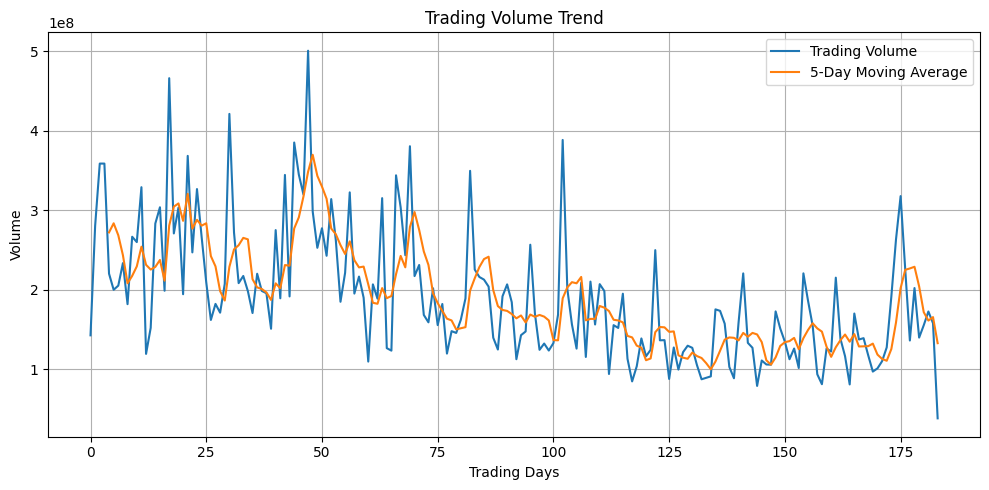

In [22]:
df["Volume_MA"] = df["Volume"].rolling(5).mean()
plt.figure(figsize=(10, 5))

plt.plot(df["Volume"], label="Trading Volume")
plt.plot(df["Volume_MA"], label="5-Day Moving Average")

plt.title("Trading Volume Trend")
plt.xlabel("Trading Days")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**5. ANOMALOUS TRADING DAYS**

In [23]:
mean_volume = df["Volume"].mean()
std_volume = df["Volume"].std()

***Volume outside ±2 standard deviations***

In [24]:
df["Volume_Anomaly"] = (
    abs(df["Volume"] - mean_volume) > 2 * std_volume
)

anomalies = df[df["Volume_Anomaly"]]

print("\nAnomalous Trading Days:")
print(anomalies[["Volume"]])


Anomalous Trading Days:
        Volume
2    358539800
3    358532900
17   465842700
21   368216200
30   420972300
44   385000600
47   500363000
69   380336500
102  388228200


***Visualization 2: Anomalous Days***

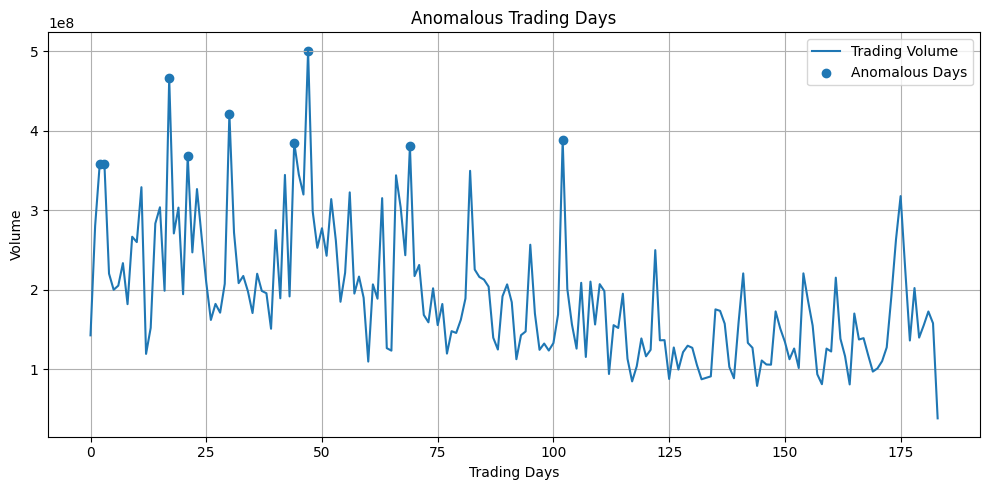

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(df.index, df["Volume"], label="Trading Volume")

plt.scatter(
    anomalies.index,
    anomalies["Volume"],
    label="Anomalous Days"
)

plt.title("Anomalous Trading Days")
plt.xlabel("Trading Days")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**6. STOCK RETURN DISTRIBUTION**

In [26]:
mean_return = df["Daily_Return"].mean()
variance_return = df["Daily_Return"].var()
std_return = df["Daily_Return"].std()

print("\nStock Return Distribution")
print("--------------------------------")
print("Mean                 :", mean_return)
print("Variance             :", variance_return)
print("Standard Deviation   :", std_return)


Stock Return Distribution
--------------------------------
Mean                 : 0.30716273695058094
Variance             : 12.289199177244166
Standard Deviation   : 3.5055954098047546


***Visualization 3: Return Distribution***

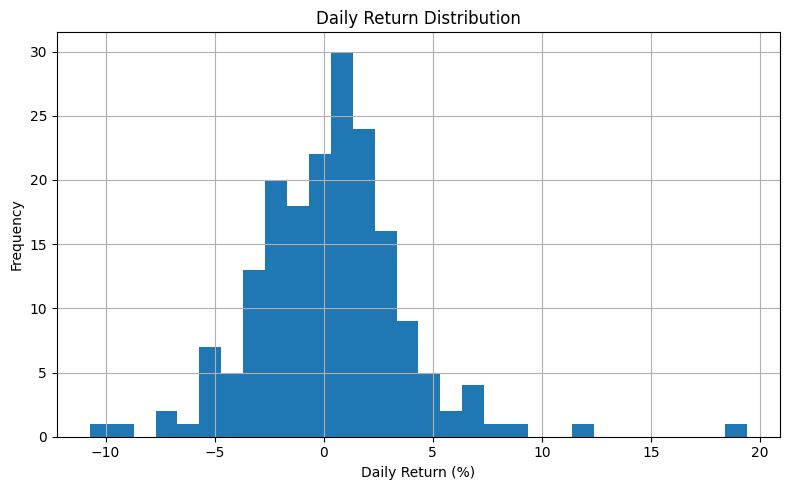

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["Daily_Return"], bins=30)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

**7. FINAL SUMMARY**

In [28]:
print("\n========== FINAL SUMMARY ==========")
print("Total Clean Records    :", len(df))
print("Average Daily Return   :", mean_return)
print("Return Variance        :", variance_return)
print("Return Std Deviation   :", std_return)
print("Average Trading Volume :", df["Volume"].mean())
print("Anomalous Days         :", len(anomalies))


========== FINAL SUMMARY ==========
Total Clean Records    : 184
Average Daily Return   : 0.30716273695058094
Return Variance        : 12.289199177244166
Return Std Deviation   : 3.5055954098047546
Average Trading Volume : 191016776.11413044
Anomalous Days         : 9
